In [ ]:
!pip install -r requirements.txt

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt

In [78]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

In [79]:
incedets_master = pd.read_csv("Dados/originais/incidents_master.csv")

In [80]:
incedets_master.head(3)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [81]:
incedets_master.isnull().sum()

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

In [82]:
incedets_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    str    
 1   company_name              850 non-null    str    
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    str    
 4   industry_primary          850 non-null    str    
 5   industry_secondary        153 non-null    str    
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    str    
 9   incident_date             850 non-null    str    
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    str    
 12  disclosure_date           850 non-null    str    
 13  attack_vector_primary     850 non-null    str    
 14  attack_vector_seconda

In [83]:
incedets_master.describe()

,company_revenue_usd,employee_count,data_compromised_records,downtime_hours,confidence_tier,quality_score
count,8.500000e+02,8.500000e+02,6.020000e+02,420.000000,850.000000,850.000000
mean,1.031337e+10,5.433418e+04,2.708462e+06,107.208762,2.215294,79.963047
std,2.106158e+10,1.266599e+05,2.978069e+07,184.645681,1.202472,12.209540
min,2.424181e+07,6.700000e+01,1.000000e+03,1.830000,1.000000,50.040000
25%,2.327545e+08,1.087000e+03,1.200500e+04,25.822500,1.000000,71.727500
50%,1.261375e+09,6.219500e+03,5.613300e+04,53.600000,2.000000,80.815000
75%,8.692943e+09,4.359475e+04,2.891170e+05,119.800000,3.000000,90.072500
max,1.488980e+11,1.411332e+06,5.497365e+08,1951.620000,4.000000,99.780000


In [84]:
incedets_master_bronze = incedets_master.apply(lambda x: create_bronze_df(x, "incedets_master.parquet"), axis=1)

In [85]:
if Path("Dados/bronze/incedets_master_bronze.parquet").exists() :
    os.remove('Dados/bronze/incedets_master_bronze.parquet')
   

In [86]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [87]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/incedets_master_bronze.parquet").exists()) :
        incedets_master_bronze.to_parquet('incedets_master_bronze.parquet')
        shutil.move('incedets_master_bronze.parquet','Dados/bronze')

In [88]:
print(incedets_master_bronze.isnull().sum()/incedets_master_bronze.shape[0] * 100)

incident_id                  0.000000
company_name                 0.000000
company_revenue_usd          0.000000
country_hq                   0.000000
industry_primary             0.000000
industry_secondary          82.000000
employee_count               0.000000
is_public_company            0.000000
stock_ticker                51.529412
incident_date                0.000000
incident_date_estimated      0.000000
discovery_date               0.000000
disclosure_date              0.000000
attack_vector_primary        0.000000
attack_vector_secondary     75.176471
attack_chain                32.352941
attributed_group            43.294118
attribution_confidence      43.294118
data_compromised_records    29.176471
data_type                   29.176471
systems_affected             0.000000
downtime_hours              50.588235
data_source_primary          0.000000
data_source_secondary       54.588235
data_source_type             0.000000
confidence_tier              0.000000
quality_scor

<Axes: >

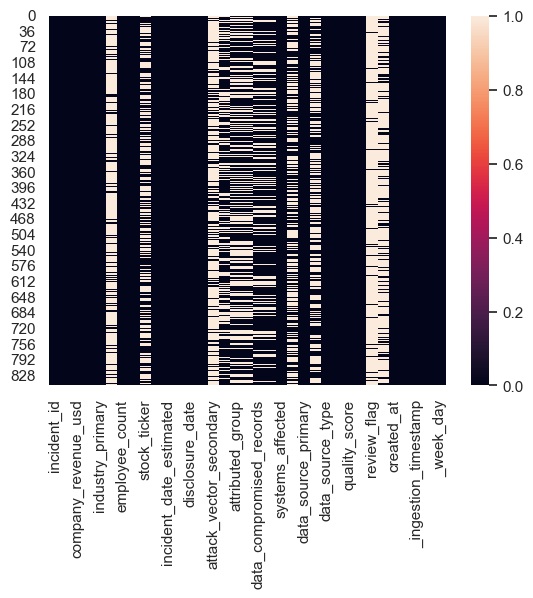

In [89]:
sns.heatmap(incedets_master_bronze.isnull())

In [90]:
print(incedets_master_bronze.duplicated(subset=['incident_id']).value_counts(),incedets_master_bronze.duplicated().sum())

False    850
Name: count, dtype: int64 0


In [91]:
incedets_master_bronze.dtypes

incident_id                            str
company_name                           str
company_revenue_usd                float64
country_hq                             str
industry_primary                       str
industry_secondary                     str
employee_count                       int64
is_public_company                     bool
stock_ticker                           str
incident_date                          str
incident_date_estimated               bool
discovery_date                         str
disclosure_date                        str
attack_vector_primary                  str
attack_vector_secondary                str
attack_chain                           str
attributed_group                       str
attribution_confidence                 str
data_compromised_records           float64
data_type                              str
systems_affected                       str
downtime_hours                     float64
data_source_primary                    str
data_source

camada prata ================================

In [92]:
def transformar_para_prata(df_bronze):
    df = df_bronze.copy()
    
    # 1. Remoção de Duplicidades (Exigência da Lauda)
    # Removemos linhas com o mesmo incident_id
    total_antes = len(df)
    df = df.drop_duplicates(subset=['incident_id'], keep='last')
    print(f"Deduplicação: {total_antes - len(df)} linhas duplicadas removidas.")

    # 2. Tratamento de Nulos (Exigência Crítica da Lauda)
    # Colunas numéricas: se for nulo, assumimos que não houve impacto ou registro (0)
    colunas_numericas = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
    for col in colunas_numericas:
        if col in df.columns:
            df[col] = df[col].fillna(0)
            
    # Colunas categóricas: padronizamos e preenchemos com 'desconhecido'
    colunas_categoricas = [
        'country_hq', 'industry_primary', 'industry_secondary', 
        'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 
        'attributed_group', 'attribution_confidence', 'data_type', 
        'systems_affected', 'data_source_type'
    ]
    for col in colunas_categoricas:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
            df[col] = df[col].replace('nan', 'desconhecido').fillna('desconhecido')
            
    # Notas e Flags: preenchimento padrão
    if 'notes' in df.columns:
        df['notes'] = df['notes'].fillna('')
    if 'review_flag' in df.columns:
        df['review_flag'] = df['review_flag'].fillna('pendente')

    # 3. Tratamento de Datas (Exigência da Lauda)
    colunas_data = ['incident_date', 'discovery_date', 'disclosure_date', 'created_at', 'updated_at']
    for col in colunas_data:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # 4. Criação do Label final para Machine Learning (Exigência da Lauda)
    # Label: O incidente resultou em tempo de inatividade/downtime? (1 = Sim, 0 = Não)
    df['label_downtime_ocorreu'] = np.where(df['downtime_hours'] > 0, 1, 0)

    # 5. Prevenção de Data Leakage (Exigência Crítica da Lauda)
    # Se queremos prever se haverá downtime na triagem inicial, não podemos usar dados de pós-incidente.
    colunas_leakage = [
        'downtime_hours',          # Revela diretamente o target
        'notes',                   # Pode conter detalhes do desfecho
        'review_flag',             # Preenchido após o encerramento pela equipe humana
        'quality_score',           # Calculado após o fechamento do registro
        'quality_grade',           # Calculado após o fechamento do registro
        'disclosure_date'          # Data de divulgação, sabida apenas depois do fato
    ]
    
    # Mantemos uma versão completa para análises e outra limpa para ML
    df_silver_completo = df.copy()
    df_silver_ml = df.drop(columns=[col for col in colunas_leakage if col in df.columns])
    
    return df_silver_completo, df_silver_ml

In [93]:
# Execução (usando a sua variável incedets_master_bronze)
incedets_master_silver, incedets_master_silver_ml = transformar_para_prata(incedets_master_bronze)

Deduplicação: 0 linhas duplicadas removidas.


In [94]:
print("\nShape do dataset completo para análise:", incedets_master_silver.shape)
print("Shape do dataset pronto para ML:", incedets_master_silver_ml.shape)


Shape do dataset completo para análise: (850, 36)
Shape do dataset pronto para ML: (850, 30)


In [95]:
if Path("Dados/prata/incedets_master_silver.parquet").exists() :
    os.remove('Dados/prata/incedets_master_silver.parquet')
    os.remove('Dados/prata/incedets_master_silver_ml.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)


if Path("Dados/prata").exists():
    if not (Path("Dados/prata/incedets_master_silver.parquet").exists()) :
        incedets_master_silver.to_parquet('incedets_master_silver.parquet', compression='snappy')
        shutil.move('incedets_master_silver.parquet','Dados/prata')
        incedets_master_silver_ml.to_parquet('incedets_master_silver_ml.parquet', compression='snappy')
        shutil.move('incedets_master_silver_ml.parquet','Dados/prata')

In [96]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

C:\Users\dudup\AppData\Local\Temp\ipykernel_13460\1946770133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_downtime_ocorreu', data=incedets_master_silver, palette='Set2')


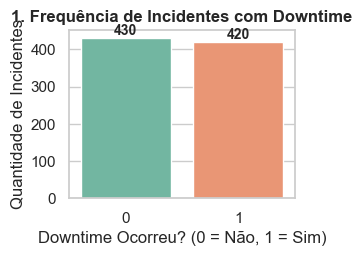

In [97]:
plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_downtime_ocorreu', data=incedets_master_silver, palette='Set2')
plt.title('1. Frequência de Incidentes com Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Downtime Ocorreu? (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Incidentes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

C:\Users\dudup\AppData\Local\Temp\ipykernel_13460\2637561295.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attack_vector_primary', y='downtime_hours', data=downtime_positivos, palette='coolwarm')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'ransomware'),
  Text(1, 0, 'apt'),
  Text(2, 0, 'ddos'),
  Text(3, 0, 'malware'),
  Text(4, 0, 'supply_chain')])

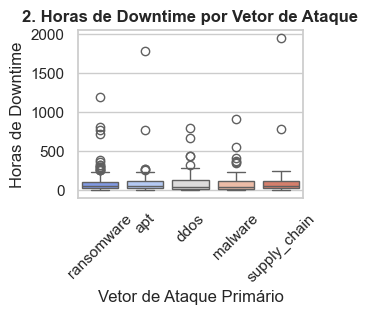

In [98]:
plt.subplot(2, 2, 2)
downtime_positivos = incedets_master_silver[
    (incedets_master_silver['downtime_hours'] > 0) & 
    (incedets_master_silver['attack_vector_primary'] != 'desconhecido')
]

sns.boxplot(x='attack_vector_primary', y='downtime_hours', data=downtime_positivos, palette='coolwarm')
plt.title('2. Horas de Downtime por Vetor de Ataque', fontsize=12, fontweight='bold')
plt.xlabel('Vetor de Ataque Primário')
plt.ylabel('Horas de Downtime')
plt.xticks(rotation=45)

Text(0, 0.5, 'Horas de Downtime')

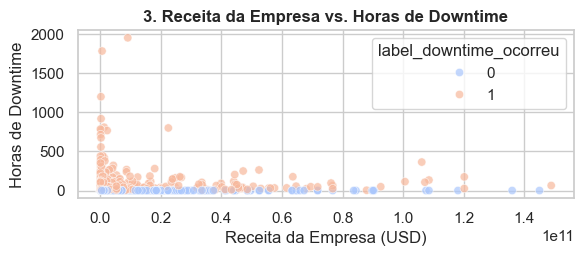

In [99]:
plt.subplot(2, 1, 2)
sns.scatterplot(x='company_revenue_usd', y='downtime_hours', 
                hue='label_downtime_ocorreu', alpha=0.7, palette='coolwarm',
                data=incedets_master_silver[incedets_master_silver['company_revenue_usd'] > 0])
plt.title('3. Receita da Empresa vs. Horas de Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Receita da Empresa (USD)')
plt.ylabel('Horas de Downtime')

RELATÓRIO TÉCNICO DO PROJETO
Construção das Camadas Bronze e Prata para Dados de Machine Learning

Dataset: incidents_master (Gestão e Mapeamento de Incidentes de Cibersegurança)
1. Representação do Data Lineage (Linhagem dos Dados)

Para garantir a governança e a rastreabilidade dos dados, o pipeline foi desenhado seguindo o fluxo abaixo:

    Origem (Raw Data): Arquivo incidents_master.csv contendo dados brutos sobre incidentes cibernéticos.

    Camada Bronze: O arquivo CSV foi lido e persistido como incedets_master_bronze.parquet. Nesta etapa, não houve alteração nas regras de negócio, apenas a inserção de metadados de auditoria: _ingestion_timestamp, _source_file e _week_day.

    Camada Prata (Completa): Leitura da camada Bronze e aplicação de regras de limpeza (deduplicação, tipagem de datas, preenchimento de nulos) e criação da variável alvo (Label). Salvo como incedets_master_silver.parquet.

    Camada Prata (Pronta para ML): Um subset derivado da camada Prata, focado exclusivamente no treinamento de modelos preditivos, com a eliminação de variáveis que geram vazamento de dados (Data Leakage). Salvo como incedets_master_silver_ml.parquet.

2. Relatório de Qualidade de Dados (Camada Bronze)

Após a carga na camada Bronze, foi realizada uma avaliação diagnóstica da qualidade dos dados brutos. Os principais problemas identificados foram:

    Inconsistências de Tipo: Datas como incident_date, disclosure_date e created_at estavam armazenadas como texto (string).

    Valores Nulos Críticos: Muitas colunas apresentavam lacunas severas de preenchimento. Colunas como downtime_hours e data_compromised_records continham nulos onde a ausência de valor indicava ausência de impacto, mas que poderiam quebrar algoritmos de ML. Categorias como attack_vector_secondary possuíam alto volume de dados ausentes.

    Duplicidades Potenciais: Necessidade de garantir a unicidade de cada registro baseado no identificador único incident_id.

    Capitalização de Strings: Textos preenchidos por diferentes operadores apresentavam variações de maiúsculas, minúsculas e espaços em excesso.

3. Construção da Camada Prata e Transformações

A camada Prata foi construída aplicando automações de validação e limpeza para resolver os problemas citados no relatório de qualidade.
Transformações Aplicadas:

    Deduplicação: Executado o comando drop_duplicates(subset=['incident_id']) para garantir que cada incidente apareça apenas uma vez.

    Padronização de Texto: Todas as colunas de texto categóricas foram convertidas para caixa baixa e tiveram os espaços das extremidades removidos.

    Tratamento de Nulos Numéricos: Para colunas como downtime_hours e company_revenue_usd, os valores nulos foram substituídos por 0.

    Tratamento de Nulos Categóricos: Onde não havia informação (ex: attack_vector_primary), o dado nulo foi preenchido com a string 'desconhecido', evitando a perda de linhas completas para o modelo.

    Tipagem de Datas: Conversão das colunas temporais para o padrão datetime64 do pandas.

Definição do Label de Machine Learning:

Com o intuito de treinar um modelo capaz de prever a gravidade operacional de um ataque no momento em que ele é detectado, criamos a variável alvo:

    label_downtime_ocorreu: Atribuído valor 1 se o incidente resultou em qualquer hora de paralisação (downtime_hours > 0) e 0 caso contrário.

4. Tabela de Checklist Anti-Leakage (Prevenção de Vazamento de Dados)

O vazamento de dados acontece quando o modelo de ML tem acesso, durante o treinamento, a informações que ele não saberia no momento real da predição. Para mitigar esse risco e cumprir a exigência da lauda, as seguintes colunas foram removidas do dataset de treinamento (incedets_master_silver_ml.parquet):
Coluna Removida	Motivo da Remoção / Risco de Leakage
downtime_hours	Variável base que originou o Label. O modelo não pode conhecê-la antes de prever.
notes	Textos livres redigidos pela equipe de resposta contendo o desfecho do incidente.
review_flag	Marcador de auditoria humana preenchido apenas após a conclusão do caso.
quality_score	Nota atribuída ao registro consolidado após a investigação estar concluída.
quality_grade	Classificação de qualidade gerada no encerramento do reporte.
disclosure_date	Data em que o incidente foi a público. Só é conhecida muito tempo depois da triagem inicial.
5. Análise Exploratória de Dados (Identificação de Padrões)

Atendendo à exigência de criar no mínimo 3 visualizações gráficas após a camada Prata, foram geradas as seguintes análises:

    Distribuição do Label de Downtime: Gráfico de contagem revelando o balanceamento entre incidentes que pararam as operações das empresas vs. incidentes que foram contidos sem gerar tempo de inatividade. Essencial para a estratégia de modelagem.

    Boxplot de Horas de Downtime por Vetor de Ataque: Demonstrou quais métodos de ataque (vetores primários) tendem a deixar sistemas fora do ar por mais tempo e a presença de casos extremos (outliers).

    Dispersão de Receita da Empresa vs. Horas de Downtime: Avaliou se empresas de maior faturamento sofrem paradas operacionais mais longas ou se o tamanho da empresa não dita diretamente o tempo de resposta e recuperação.

Conclusão

O pipeline desenvolvido cumpre rigorosamente as boas práticas de engenharia de dados estipuladas. Os dados foram extraídos, auditados na Bronze, limpos e enriquecidos na Prata, gerando um insumo final confiável, documentado e blindado contra vazamento de dados para o time de Machine Learning.